# 🧬 Clasificando Secuencias Biológicas con Deep Learning

### 🧪 Taller práctico — PyLadies Cuernavaca  
📅 **12 de septiembre de 2025**  
👩🏻‍💻 **@Alida_Zárate**  
🔗 [github.com/alyzart22](https://github.com/alyzart22)

---

## 📝 Descripción

En este taller aprenderemos cómo usar técnicas de *Deep Learning* para clasificar proteínas virales a partir de sus secuencias aminoacídicas. Usaremos redes neuronales convolucionales y codificación *one-hot* para procesar los datos biológicos.

### Clases a clasificar:
-  **SARS-CoV-2**
-  **Orthoherpesviridae**
-  **Bacteriófagos**

Este taller está orientado a personas con conocimientos básicos de Python, interesadas en bioinformática y ciencia de datos.

---


# Instalar Dependencias

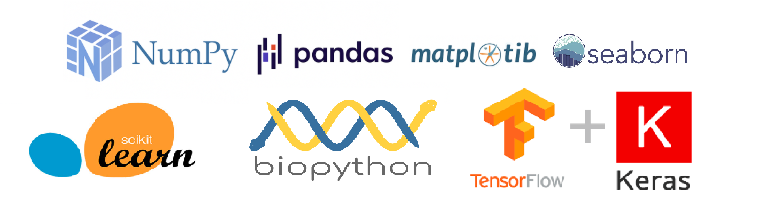

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.4 MB/s eta 0:00:00


In [128]:
from Bio import SeqIO
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random #USado para shuffle batch registros
random.seed(10) #Inicializamos la semilla
from datetime import datetime
from IPython.display import Image, display
from tqdm.notebook import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [136]:
#Librerias para IA
import tensorflow as tf
from tensorflow.python.client import device_lib
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import L2, L1
from tensorflow.keras.layers import Input, Dropout, Activation,Conv1D, Add, MaxPooling1D, BatchNormalization, Conv2D, Add, MaxPooling2D, ReLU, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from google.colab import files

# Verificar conectividad a GPU
Unidad de Procesamiento Gráfico.
Es un procesador especializado en realizar cálculos masivos en paralelo, diseñado originalmente para gráficos, pero hoy muy usado en inteligencia artificial y ciencia de datos.

In [13]:
print(":::::::::::::::::::::::::::::::::: CHECK GPU ::::::::::::::::::::::::::::::::::::")

# Versión de TensorFlow
print("**** Versión de TensorFlow ****", tf.__version__)

# GPUs detectadas
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))

# Mostrar nombre del dispositivo GPU (si existe)
if gpus:
    for i, gpu in enumerate(gpus):
        print(f"GPU {i}: {gpu}")
else:
    print("⚠️ No se detectó ninguna GPU con TensorFlow")

# Información más detallada de dispositivos
local_device_protos = device_lib.list_local_devices()
for x in local_device_protos:
    if x.device_type == 'GPU':
        print("Nombre GPU detectada por TF:", x.physical_device_desc)

print(":::::::::::::::::::::::::::::::::: FIN CHECK GPU ::::::::::::::::::::::::::::::::")


:::::::::::::::::::::::::::::::::: CHECK GPU ::::::::::::::::::::::::::::::::::::
**** Versión de TensorFlow **** 2.19.0
Num GPUs Available: 1
GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Nombre GPU detectada por TF: device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
:::::::::::::::::::::::::::::::::: FIN CHECK GPU ::::::::::::::::::::::::::::::::


# Cargar Archivos Fasta de las 3 clases

In [16]:
#Montar  drive personal
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [17]:
!ls

drive  sample_data


In [18]:
%cd drive/MyDrive/Pyladies_DeepLearning
!ls

/content/drive/MyDrive/Pyladies_DeepLearning
Curso_Pyladies_Clasificando_Proteinas_Deep_Learning.ipynb  img
Data							   Resumen.docx
DeepLearning_Para_Secuencias_Biologicas.pptx


In [19]:
# Obtener el directorio donde está la notebook
BASE_DIR = os.getcwd()
print("Directorio base:", BASE_DIR)



# Carpeta Data relativa al directorio base
DATA_DIR = os.path.join(BASE_DIR, "Data")
print("Carpeta de datos:", DATA_DIR)

# Ejemplo: leer un archivo de Data
Sars_fasta_ruta = os.path.join(DATA_DIR, "Sars-CoV-2.fasta")
Orthoherpesviridae_fasta_ruta = os.path.join(DATA_DIR, "Orthoherpesviridae.fasta")
Bacteriofagos_fasta_ruta = os.path.join(DATA_DIR, "Bacteriofagos.fasta")


print("Ruta de los 3 archivos fasta a procesar")
print(Sars_fasta_ruta)
print(Orthoherpesviridae_fasta_ruta)
print(Bacteriofagos_fasta_ruta)


Directorio base: /content/drive/MyDrive/Pyladies_DeepLearning
Carpeta de datos: /content/drive/MyDrive/Pyladies_DeepLearning/Data
Ruta de los 3 archivos fasta a procesar
/content/drive/MyDrive/Pyladies_DeepLearning/Data/Sars-CoV-2.fasta
/content/drive/MyDrive/Pyladies_DeepLearning/Data/Orthoherpesviridae.fasta
/content/drive/MyDrive/Pyladies_DeepLearning/Data/Bacteriofagos.fasta


## Veamos las Secuencias

In [20]:
def mostrar_raw_fasta(fasta_path, n):
    """Muestra las primeras n líneas de un archivo FASTA en formato raw"""
    print(f"\n📂 Archivo: {fasta_path.split('/')[-1]}")
    with open(fasta_path, "r") as f:
        for i, linea in enumerate(f):
            if i >= n:   # limitar número de líneas
                break
            print(linea.strip())  # strip() quita saltos extra, pero conserva el formato

In [21]:
for ruta in [Sars_fasta_ruta, Orthoherpesviridae_fasta_ruta, Bacteriofagos_fasta_ruta]:
    mostrar_raw_fasta(ruta, n=4)  # muestra 20 líneas de cada archivo


📂 Archivo: Sars-CoV-2.fasta
>XDI95720.1 |Coronaviridae|Betacoronavirus|Betacoronavirus pandemicum|BF.7.14|Homo sapiens|China|ORF1a polyprotein [Severe acute respiratory syndrome coronavirus 2]|4402
MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKNGNKGAGGHRYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAWYTERSEKSYELQTPFEIKLAKKFDTFNGECPNFLFPLNSIIKTIQPRVEKKKLDGFMGRIRSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYLPQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKCAYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASFSASTSAFVETVKGLDYKVFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEAARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAYITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIVGGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKCVKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVGTPVCINGLMLLEIKDTEKYCA

In [22]:
#funcion para mostrar las secuencias
def mostrar_secuencias(fasta_path, n):
    """Muestra las primeras n secuencias de un archivo fasta (encabezado + secuencia)."""
    print(f"\n📂 Archivo: {fasta_path.split('/')[-1]}")
    for i, record in enumerate(SeqIO.parse(fasta_path, "fasta")):
        if i >= n:
            break
        print(f"\nEncabezado: {record.description}")   # encabezado completo (> ...)
        print(f"Longitud: {len(record.seq)}")
        print(f"Secuencia (primeros 80 aa): {str(record.seq)[:80]}{'...' if len(record.seq) > 80 else ''}")


In [23]:
# Mostrar secuencias de los 3 archivos
for ruta in [Sars_fasta_ruta, Orthoherpesviridae_fasta_ruta, Bacteriofagos_fasta_ruta]:
    mostrar_secuencias(ruta, n=1)


📂 Archivo: Sars-CoV-2.fasta

Encabezado: XDI95720.1 |Coronaviridae|Betacoronavirus|Betacoronavirus pandemicum|BF.7.14|Homo sapiens|China|ORF1a polyprotein [Severe acute respiratory syndrome coronavirus 2]|4402
Longitud: 4402
Secuencia (primeros 80 aa): MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAP...

📂 Archivo: Orthoherpesviridae.fasta

Encabezado: URN71642.1 |Orthoherpesviridae|Cytomegalovirus|Cytomegalovirus humanbeta5|Homo sapiens|Germany|Germany|1999-03-15|tegument protein UL25 [Human betaherpesvirus 5]|656
Longitud: 656
Secuencia (primeros 80 aa): MSSRRRSSSRRSGEPSTVIYIPSSNEDTPADEEAEDSVFTSTRARSATEDLDRMEAGLSPYSVSSDAPSSFELVRETGGT...

📂 Archivo: Bacteriofagos.fasta

Encabezado: QIN96853.1|Myoviridae
Longitud: 462
Secuencia (primeros 80 aa): MSQHLTEKWAPVLGHQDLPEIKDSYRAAVTAQLLENQEAFLREQAAMGQGSSLLSEAVPTMSTGTNATPGAGAGNAGFGA...


## Obtener Estadistica de los archivos Fasta

In [24]:
#Fundion para obtener estadistica de los archivos 3 fasta
#Recibe la ruta de cada archivo fasta
def fasta_stats(fasta_path):
    """Lee un archivo fasta y devuelve estadísticas básicas."""
    seqs = list(SeqIO.parse(fasta_path, "fasta"))
    if not seqs:
        return None

    longitudes = [len(record.seq) for record in seqs]
    #se crea el diccionario para devolver los datos
    stats = {
        "Archivo": fasta_path.split("/")[-1],
        "Número de secuencias": len(seqs),
        "Longitud mínima": min(longitudes),
        "Longitud máxima": max(longitudes),
        "Longitud medía": round(sum(longitudes)/ len(longitudes), 2),
    }
    return stats

In [25]:
# Calcular estadísticas para cada archivo
resultados = []  # aquí guardamos cada diccionario que vamos a recibir de la funcion fasta stats

for ruta in [Sars_fasta_ruta, Orthoherpesviridae_fasta_ruta, Bacteriofagos_fasta_ruta]:
    stats = fasta_stats(ruta)
    if stats:  # solo si no está vacío
        resultados.append(stats)

# Convertir la lista de diccionarios en un DataFrame para mostrar la informacion
df_stats = pd.DataFrame(resultados)

df_stats

,Archivo,Número de secuencias,Longitud mínima,Longitud máxima,Longitud medía
0,Sars-CoV-2.fasta,2278,303,7096,3198.73
1,Orthoherpesviridae.fasta,2401,300,3753,652.30
2,Bacteriofagos.fasta,3061,300,6932,597.02


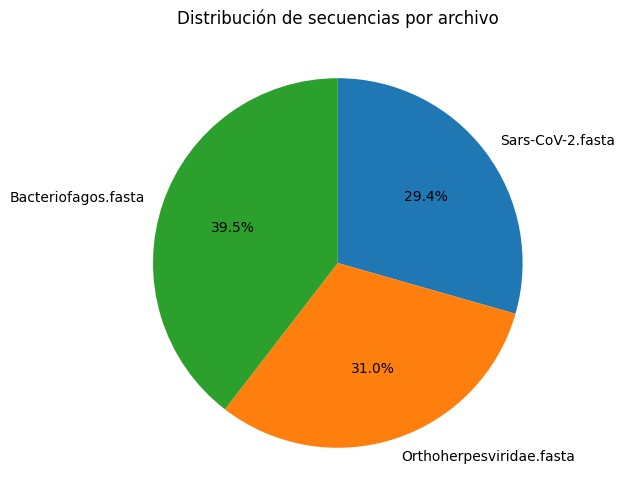

In [26]:
#¿Datos equilibrados?
labels = df_stats["Archivo"]
sizes = df_stats["Número de secuencias"]

# Crear la gráfica de pastel
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",   # mostrar porcentajes con un decimal
    startangle=90,       # empezar desde arriba
    counterclock=False   # sentido horario
)

plt.title("Distribución de secuencias por archivo")
plt.show()

# Calidad de las secuencias


---


### Estrategia

1.   Leer los FASTA con SeqIO.
2.   Contar los aminoácidos X en cada secuencia.
1.   Calcular el porcentaje de X respecto a la longitud total.


### Guardar:

Secuencias tienen más de X% de X.


In [27]:
def analizar_X(fasta_path, umbral):
    """
    Analiza un archivo fasta y calcula cuántas secuencias tienen X > umbral%
    Retorna un DataFrame con resultados por secuencia
    """
    resultados = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        secuencia = str(record.seq).upper()
        longitud = len(secuencia)
        conteo_X = secuencia.count("X") #No necesariamente contiguas
        porcentaje_X = (conteo_X / longitud) * 100 if longitud > 0 else 0

        resultados.append({
            "Archivo": fasta_path.split("/")[-1],
            "ID": record.id,
            "Longitud": longitud,
            "Conteo_X": conteo_X,
            "Porcentaje_X": round(porcentaje_X, 2)
        })

    df = pd.DataFrame(resultados)

    # Resumen rápido
    n_total = len(df)
    n_malas = (df["Porcentaje_X"] > umbral).sum()
    print(f"\n📂 {fasta_path.split('/')[-1]}: {n_total} secuencias totales")
    print(f"⚠️ {n_malas} secuencias ({n_malas/n_total*100:.1f}%) tienen más de {umbral}% de X\n")

    return df

In [28]:
# Analizar los 3 archivos
dfs = []
umbral=20
for ruta in [Sars_fasta_ruta, Orthoherpesviridae_fasta_ruta, Bacteriofagos_fasta_ruta]:
    df = analizar_X(ruta, umbral)  # por ejemplo 20%
    dfs.append(df)

# Juntar en un solo DataFrame
df_X = pd.concat(dfs, ignore_index=True)

# Ver solo las secuencias "baja calidad"
df_baja_calidad = df_X[df_X["Porcentaje_X"] > umbral]
print("Secuencias con más de", umbral,"% de X:")
display(df_baja_calidad.head(5))  # mostrar las primeras 10


📂 Sars-CoV-2.fasta: 2278 secuencias totales
⚠️ 81 secuencias (3.6%) tienen más de 20% de X


📂 Orthoherpesviridae.fasta: 2401 secuencias totales
⚠️ 2 secuencias (0.1%) tienen más de 20% de X


📂 Bacteriofagos.fasta: 3061 secuencias totales
⚠️ 2 secuencias (0.1%) tienen más de 20% de X

Secuencias con más de 20 % de X:


,Archivo,ID,Longitud,Conteo_X,Porcentaje_X
160,Sars-CoV-2.fasta,QLR12427.1,7096,1615,22.76
190,Sars-CoV-2.fasta,XKV29051.1,1270,420,33.07
266,Sars-CoV-2.fasta,XXQ28441.1,1273,659,51.77
274,Sars-CoV-2.fasta,XXQ27771.1,5849,1373,23.47
276,Sars-CoV-2.fasta,XXQ28237.1,6516,1937,29.73


cat Sars-CoV-2.fasta |sed -n 533,534p

## Quitar secuencias baja calidad
Quitar secuencias por debajo del % de Xs (aminoaciodos no reconocidos) permitido

In [29]:
def filtrar_fasta(fasta_in, fasta_out, baja_calidad_ids, umbral):
    """
    Crea un nuevo fasta_out en formato oneline:
    >header
    SECUENCIA_COMPLETA
    """
    print("Umbral:", umbral, "%")
    with open(fasta_out, "w") as out_f:
        for record in SeqIO.parse(fasta_in, "fasta"):
            if record.id not in baja_calidad_ids:
                # Escribir header y secuencia en una sola línea
                out_f.write(f">{record.description}\n{str(record.seq)}\n")
    print(f"✅ Guardado {fasta_out} (sin {len(baja_calidad_ids)} secuencias de baja calidad)")

In [30]:
# Preparar listas de IDs de baja calidad por archivo
# df_baja_calidad ya tiene las secuencias de baja calidad detectadas
baja_calidad_por_archivo = df_baja_calidad.groupby("Archivo")["ID"].apply(list).to_dict()

#  Filtrar cada archivo
for ruta in [Sars_fasta_ruta, Orthoherpesviridae_fasta_ruta, Bacteriofagos_fasta_ruta]:
    nombre_archivo = ruta.split("/")[-1]
    fasta_filtrado = ruta.replace(".fasta", "_filtrado.fasta")
    baja_calidad_ids = baja_calidad_por_archivo.get(nombre_archivo, [])
    filtrar_fasta(ruta, fasta_filtrado, baja_calidad_ids, umbral)



Umbral: 20 %
✅ Guardado /content/drive/MyDrive/Pyladies_DeepLearning/Data/Sars-CoV-2_filtrado.fasta (sin 81 secuencias de baja calidad)
Umbral: 20 %
✅ Guardado /content/drive/MyDrive/Pyladies_DeepLearning/Data/Orthoherpesviridae_filtrado.fasta (sin 2 secuencias de baja calidad)
Umbral: 20 %
✅ Guardado /content/drive/MyDrive/Pyladies_DeepLearning/Data/Bacteriofagos_filtrado.fasta (sin 2 secuencias de baja calidad)


Comprobamos el número de secuencias actual

In [31]:
#Nuevas rutas de los archivos filtrados
Sars_fasta_ruta_filtradas = os.path.join(DATA_DIR, "Sars-CoV-2_filtrado.fasta")
Orthoherpesviridae_fasta_ruta_filtradas = os.path.join(DATA_DIR, "Orthoherpesviridae_filtrado.fasta")
Bacteriofagos_fasta_ruta_filtradas = os.path.join(DATA_DIR, "Bacteriofagos_filtrado.fasta")

In [32]:
# Calcular estadísticas para cada archivo nuevamente
resultados = []  # aquí guardamos cada diccionario que vamos a recibir de la funcion fasta stats

for ruta in [Sars_fasta_ruta_filtradas, Orthoherpesviridae_fasta_ruta_filtradas, Bacteriofagos_fasta_ruta_filtradas]:
    stats = fasta_stats(ruta)
    if stats:  # solo si no está vacío
        resultados.append(stats)
# Convertir la lista de diccionarios en un DataFrame para mostrar la informacion
df_stats = pd.DataFrame(resultados)
df_stats

,Archivo,Número de secuencias,Longitud mínima,Longitud máxima,Longitud medía
0,Sars-CoV-2_filtrado.fasta,2197,303,7096,3205.35
1,Orthoherpesviridae_filtrado.fasta,2399,300,3753,652.07
2,Bacteriofagos_filtrado.fasta,3059,300,6932,597.13


In [33]:
for ruta in [Sars_fasta_ruta_filtradas, Orthoherpesviridae_fasta_ruta_filtradas, Bacteriofagos_fasta_ruta_filtradas]:
    mostrar_raw_fasta(ruta, n=4)  # muestra 20 líneas de cada archivo


📂 Archivo: Sars-CoV-2_filtrado.fasta
>XDI95720.1 |Coronaviridae|Betacoronavirus|Betacoronavirus pandemicum|BF.7.14|Homo sapiens|China|ORF1a polyprotein [Severe acute respiratory syndrome coronavirus 2]|4402
MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKNGNKGAGGHRYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAWYTERSEKSYELQTPFEIKLAKKFDTFNGECPNFLFPLNSIIKTIQPRVEKKKLDGFMGRIRSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYLPQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKCAYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASFSASTSAFVETVKGLDYKVFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEAARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAYITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIVGGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKCVKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVGTPVCINGLMLLE

# Generar el cojunto de datos
para entrenamiento, validacion y prueba.

## K-merizacion
dividir una secuencia biológica (ADN, ARN o proteína) en fragmentos cortos de longitud fija k llamados k-mers, para analizarlos o usarlos como características en modelos de IA y bioinformática.

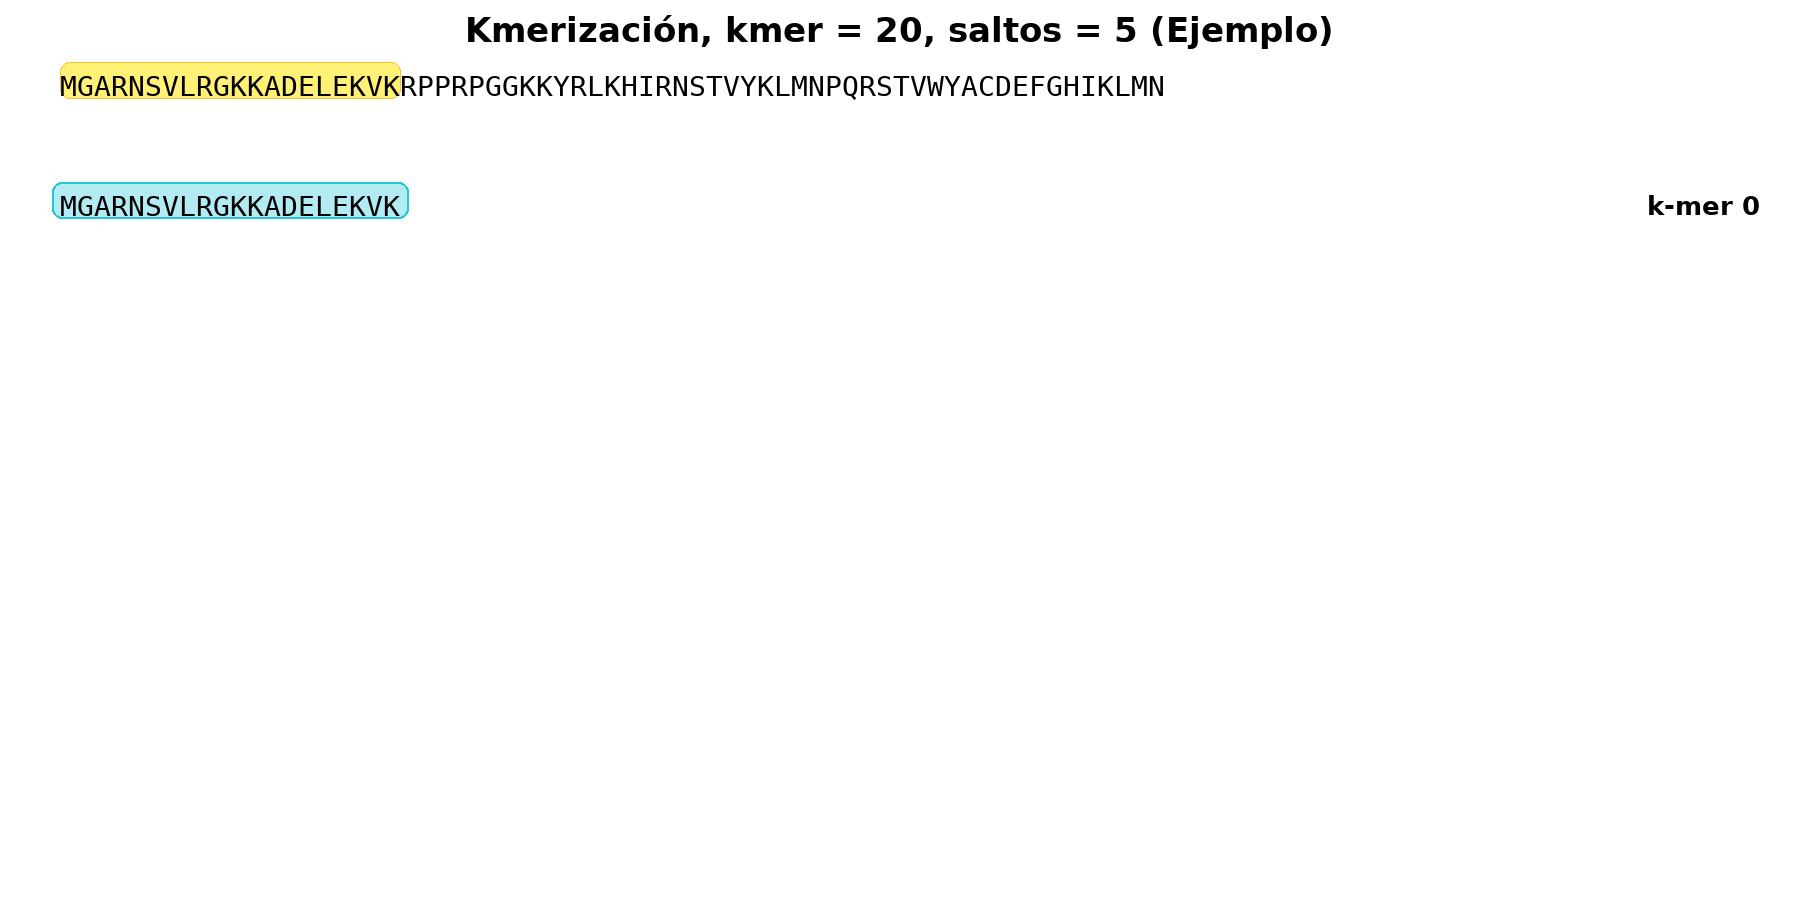

In [34]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/kmerizacion.gif"
display(Image(filename=gif_path, width=800))

In [35]:
def kmerizar_fasta(fasta_path, kmer_longitud, step, clase):
    """
    Lee un archivo fasta y devuelve un DataFrame con kmers de tamaño k
    usando ventanas con paso step.

    columnas: [Clase, Kmer]
    """
    registros = []

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq).upper()
        longitud = len(seq)

        # Generar kmers con ventana deslizante
        for i in range(0, longitud - kmer_longitud + 1, step):
            kmer = seq[i:i+kmer_longitud]
            registros.append((clase, kmer))

    df = pd.DataFrame(registros, columns=["Clase", "Kmer"])
    return df

In [36]:
kmer_longitud=300
step=40

# Crear datasets individuales
df_sars = kmerizar_fasta(Sars_fasta_ruta_filtradas, kmer_longitud, step, clase=0)
df_ortho = kmerizar_fasta(Orthoherpesviridae_fasta_ruta_filtradas, kmer_longitud, step, clase=1)
df_bacteriofago = kmerizar_fasta(Bacteriofagos_fasta_ruta_filtradas, kmer_longitud, step, clase=2)


In [37]:
df_bacteriofago

,Clase,Kmer
0,2,MSQHLTEKWAPVLGHQDLPEIKDSYRAAVTAQLLENQEAFLREQAA...
1,2,LREQAAMGQGSSLLSEAVPTMSTGTNATPGAGAGNAGFGADAAAGG...
2,2,DAAAGGPVAGFDPVMIGLIRRAMPNLMAYDICGVQPMTGPTGLIFA...
3,2,TGLIFAMRALYGGQDPTNAEALFNEADISYANNETATNSQESNPGL...
4,2,ESNPGLLNDATLGGVTPGNYDPTLASGEGAGMGTETLEDATFRQMG...
...,...,...
24342,2,MAKNNYDITIRARSGDEVTFWGSKFDDEGNEPRRIGYSGLSGLGEP...
24343,2,MRIRSIKPEFWRSDDITKLPISTRLTFIGLWSYVDDNGVGADKLVS...
24344,2,MGPHLDPQSNRILLWRGVDSGVAASWDPEALAQGRFVSKAPATWDE...
24345,2,MRTHRAGQNNRLEKFVTHDITPHAADGSPFDAGRTPCSQGGEDRWS...


In [38]:
#Unir los kmeros de las 3 clases
df_general = pd.concat([df_sars, df_ortho, df_bacteriofago], ignore_index=True)
print(df_general.head())
print("\nTamaño total del dataset:", len(df_general))


   Clase                                               Kmer
0      0  MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...
1      0  EARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMV...
2      0  HGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKN...
3      0  VLLRKNGNKGAGGHRYGADLKSFDLGDELGTDPYEDFQENWNTKHS...
4      0  WNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLA...

Tamaño total del dataset: 207092


## Split de los datos
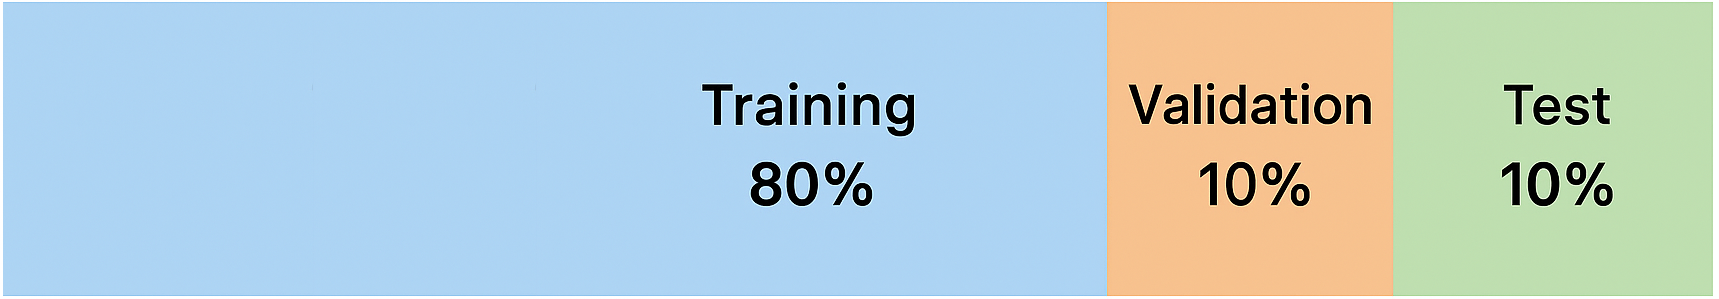

In [39]:
# Mezclar y dividir 80% entrenamiento y 20% temporal (val + test)
#train_test_split esta función es propia de sklearn

df_train, df_temp = train_test_split(df_general, test_size=0.2, stratify=df_general['Clase'], random_state=42)

# Dividir el 20% restante en 10% validación y 10% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp['Clase'], random_state=42)

#Definir automaticamente el numero de clases
clases_unicas = df_train["Clase"].unique()
num_clases = len(clases_unicas)

print(f"Entrenamiento 80% : {len(df_train)}")
print(f"Validación 10% : {len(df_val)}")
print(f"Test 10%: {len(df_test)}")
print("Numro de Clases:" , num_clases)
df_val.head()
df_temp.head()

Entrenamiento 80% : 165673
Validación 10% : 20709
Test 10%: 20710
Numro de Clases: 3


,Clase,Kmer
166057,1,TVWMSGLIRTRAAGEQQQPPSLVGTGVHRGLLTATGCCLLHNVTVH...
184757,2,MNFAGKTKEETEEATKLFKKYADDTVYELNDITNTGAQLAANGIES...
122019,0,FVDSDVETKDVVECLKLSHQSDIEVTGDSCNNYMLTYNKVENMTPR...
198063,2,RSGESAEAAKGSMIGFREVFAGSILANVAVGAVNMITDSFHKMINT...
129000,0,IIQFPNTYLEGSVRVVTTFDSEYCRHGTCERSEAGVCVSTSGRWVL...


In [40]:
#Funcion para ver la distribucion de kmers
def plot_class_distribution(df, titulo="Distribución de clases"):
    conteo = df["Clase"].value_counts().sort_index()

    # Diccionario de nombres de clases
    nombres_clases = {
        0: "Sars-CoV-2",
        1: "Orthoherpesviridae",
        2: "Bacteriofagos"
    }

    fig, ax = plt.subplots(figsize=(6,4))
    barras = conteo.plot(
        kind="bar",
        color=["#66c2a5", "#fc8d62", "#8da0cb"],
        ax=ax
    )

    # Etiquetas y título
    ax.set_xlabel("Clase")
    ax.set_ylabel("Número de secuencias (kmers)")
    ax.set_title(titulo)
    ax.set_xticks(range(len(conteo)))
    ax.set_xticklabels([nombres_clases[i] for i in conteo.index], rotation=15)

    # Agregar números encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3)

    plt.show()

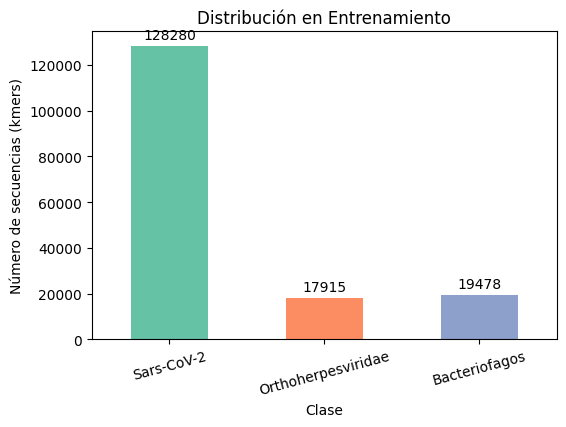

In [41]:
# Ver distribución en train/val/test
plot_class_distribution(df_train, "Distribución en Entrenamiento")
#plot_class_distribution(df_val, "Distribución en Validación")
#plot_class_distribution(df_test, "Distribución en Test")

# Representación de secuencias
Harding-Larsen(2024)

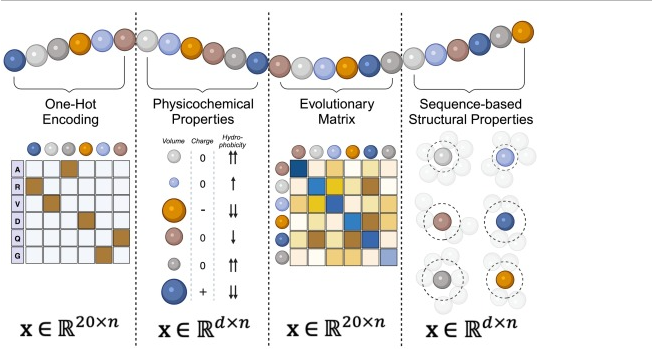

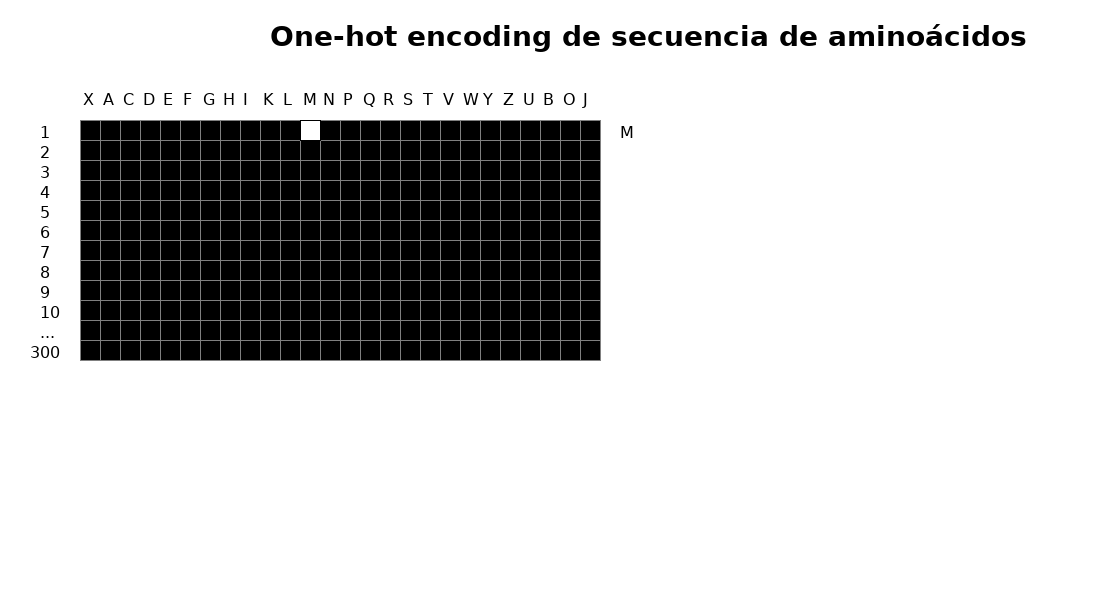

In [43]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/codificacion_one_hot_encoding.gif"
display(Image(filename=gif_path, width=800))


In [44]:
#Almacena la columna donde estan los kmers
def recorre_lineas(lista_lineas):
    lineas_kmeros=lista_lineas['Kmer'] # 0, ACFG...
    #Almacena la columna donde estan las etiquetas
    lineas_etiquetas=lista_lineas['Clase'] # por q no es la clase en si si no el codigo en orden 0-nclases
    #Convertir a letras el conjunto de lineas
    #print(lineas_kmeros)
    kmers_convertidos=conv_letra_num(lineas_kmeros)
    return kmers_convertidos, lineas_etiquetas

In [45]:
#Metodo para pasar de letras a números
def conv_letra_num(secuencia):
    #print(secuencia)
    Lette_dict = {'X': 0,'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20,'Z': 21,'U':22, 'B':23, 'O':24,'J':25}
    seq_list = list(secuencia)
    seq_list = [Lette_dict[base] for base in seq_list]
    return seq_list

### Vamos a hacer un generador

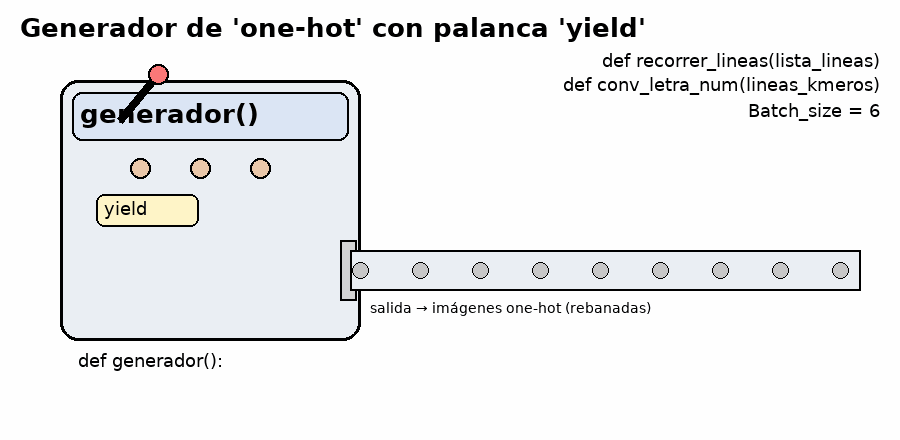

In [46]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/generador.gif"
display(Image(filename=gif_path, width=800))

In [47]:
def generador(muestra,  num_clases, tamano_batch,):
    total_de_muestras=len(muestra)
    print("Generador::::")
    #print(len(muestra))
    while 1:
        for x in range(0, total_de_muestras, tamano_batch):
            #crea los chunks a partir de las muestras
            muestras_batch=muestra[x:x+tamano_batch]
            lista_datos=[]
            lista_etiquetas=[]
            #recorremos cada linea del batch para pasar a categorico
            '''for muestras_batch in muestras_batch:
                print(muestras_batch)
                linea_nueva, etiqueta = recorre_lineas(muestras_batch)
                lista_datos.append(linea_nueva)
                lista_etiquetas.append(etiqueta)'''

            # recorrer cada fila del batch (fila es un pd.Series con encabezados)
            for _, fila in muestras_batch.iterrows():
                linea_nueva, etiqueta = recorre_lineas(fila)
                lista_datos.append(linea_nueva)
                lista_etiquetas.append(etiqueta)
            #SECUENCIAS
            #transforma la lista a un arreglo de numpy para hacer operacion (vectorizacion)
            x_data=np.array(lista_datos, dtype='uint8')
            x_data=to_categorical(x_data,num_classes=26) # <--- Aqui se hace la convercion a One-hot
            x_data = x_data.astype("uint8")

            #ETIQUETAS
            df_batch_etiquetas=pd.DataFrame(np.array(lista_etiquetas), index=None)
            y_data=df_batch_etiquetas.iloc[:,0:1]
            y_data=np.array(y_data, dtype='uint8')#Para este ejemplo de 3 clases es suficiente codificar en uint8, 0,1,y 2 se puede codificar en 8 bits (1 byte), uint16 mas para mas> 255
            y_data=to_categorical(y_data, num_classes=num_clases)
            y_data = y_data.astype("uint8")
            yield x_data,y_data

In [48]:
#Verificar el generador Ejemplo para visualizar
# Crear un generador
gen = generador(df_test, num_clases, tamano_batch=3)



In [49]:
# Obtener el primer batch
x_batch, y_batch = next(gen)
print("X_batch shape:", x_batch.shape)
print("Y_batch shape:", y_batch.shape)
print("Ejemplo de X_batch[0]:")
print(x_batch[0].shape)
print(x_batch[0])
print("Ejemplo de Y_batch[0]:")
print(y_batch[0].shape)
print(y_batch[0])

Generador::::
X_batch shape: (3, 300, 26)
Y_batch shape: (3, 3)
Ejemplo de X_batch[0]:
(300, 26)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Ejemplo de Y_batch[0]:
(3,)
[1 0 0]


In [50]:
#Guardar diccionario labels
label_dict = {
    0: "SARS-CoV-2",
    1: "Orthoherpesviridae",
    2: "Bacteriófago"
}
#0 --> [1, 0, 0]
#1 --> [0, 1, 0]
#2 --> [0, 0, 1]


# Entrenar modelo
Definir hiperparametros
*   BatchSize (8,16,32,64,128,256,512,024)
*   Learning_rate (0.00001, 0.0001, 0.001 )
*   Epocas (puede variar)
*   Numero_filtros (16,32,64,128,256)
*   tamano_kernel (3,5,7,9)






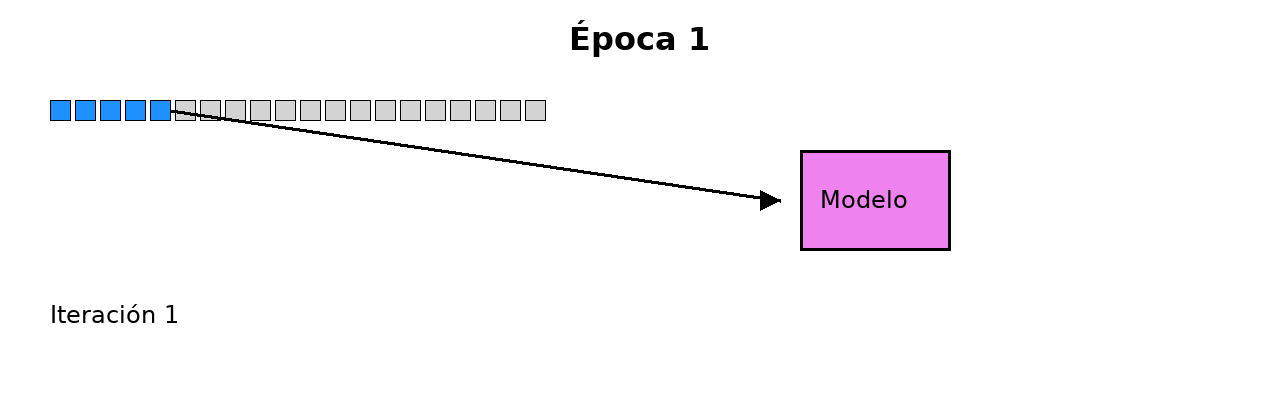

In [160]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/epocas.gif"
display(Image(filename=gif_path, width=800))

### Función de pérdida (cross entropy)
 Mide qué tan diferente es la predicción del modelo respecto a la etiqueta real. Mientras más baja, mejor está aprendiendo.

### Gradiente  
Indica la dirección en la que debemos movernos para reducir esa pérdida.

### Learning rate
Define el tamaño del paso que damos en esa dirección.

**Así, la función de pérdida es el “mapa”, el gradiente es la “flecha de dirección” y el learning rate es “qué tan grande das el paso” en ese mapa.**
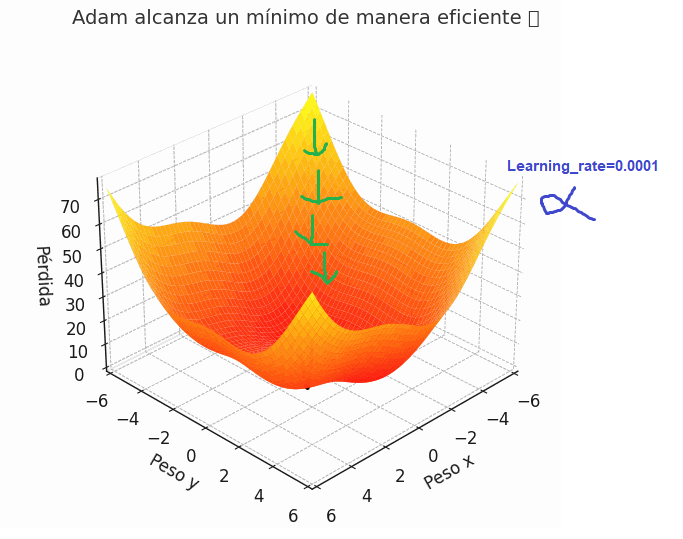

In [64]:
#Definir hiperparametros
BatchSize= 32
Learning_rate= 0.0001
Epocas=6
Numero_filtros=8
tamano_kernel=3
#num_clases= Se definio arriba
#kmer_longitud =300 Se definio arriba cuando se hicieron los kmers

In [53]:
#Hacer generadores
train_generador= generador(df_train, num_clases, BatchSize)
val_generador= generador(df_val, num_clases, BatchSize)

## Definir Estructura modelo

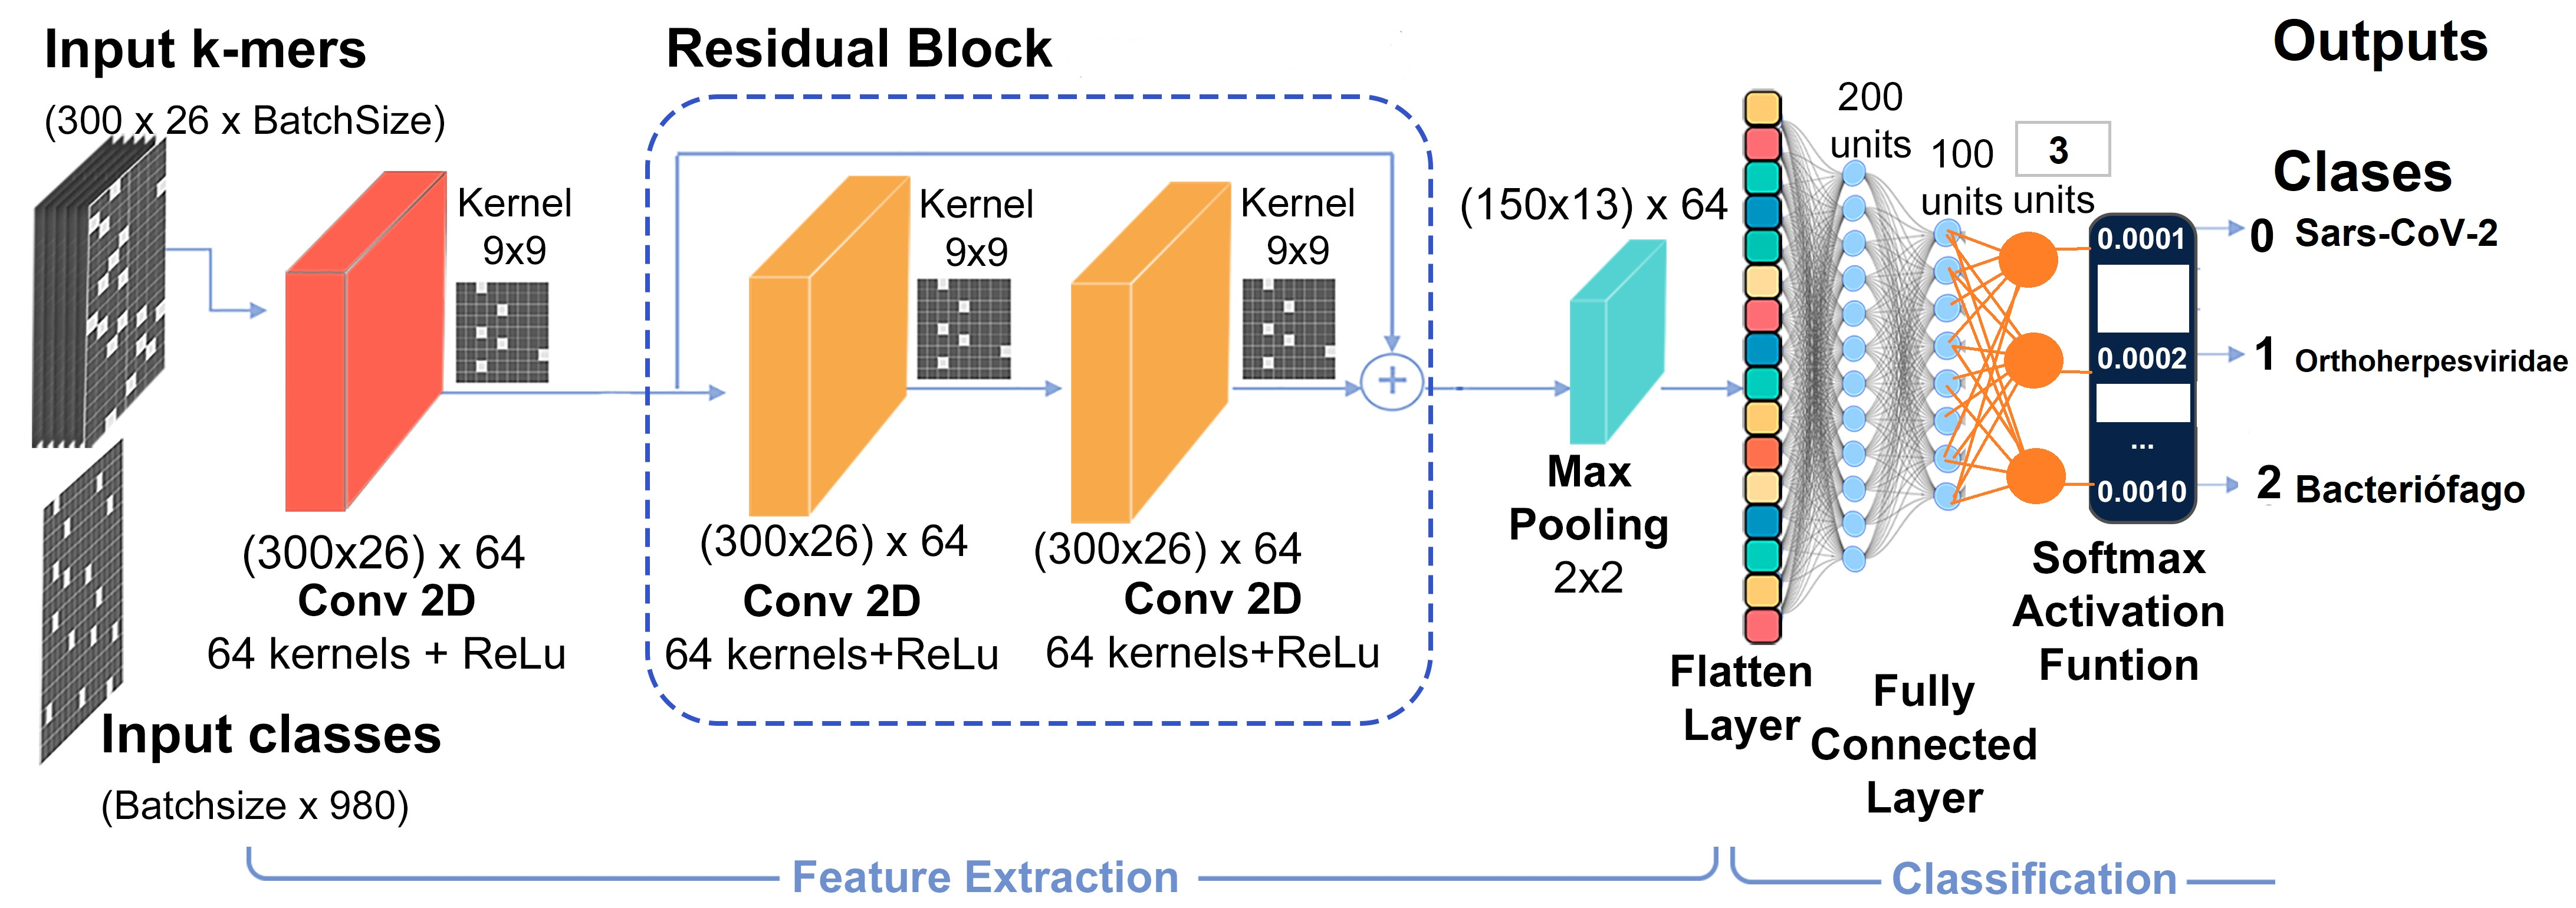

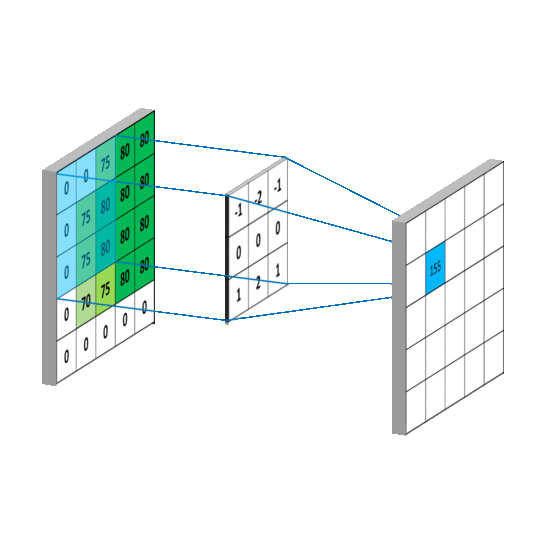

In [162]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/ejemplo_convolucion.gif"
display(Image(filename=gif_path, width=400))

**ReLU (Rectified Linear Unit)**

Definición: función de activación que deja pasar valores positivos y convierte los negativos en 0.

**Funcion(x)= max(0,x)**

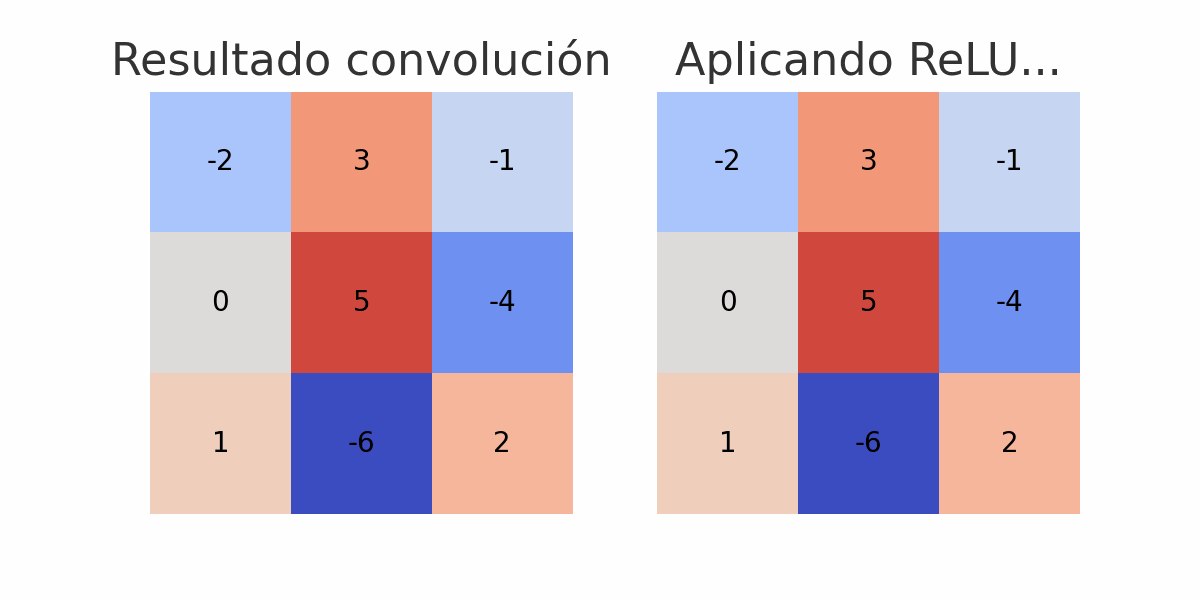

In [164]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/relu_demo.gif"
display(Image(filename=gif_path, width=400))

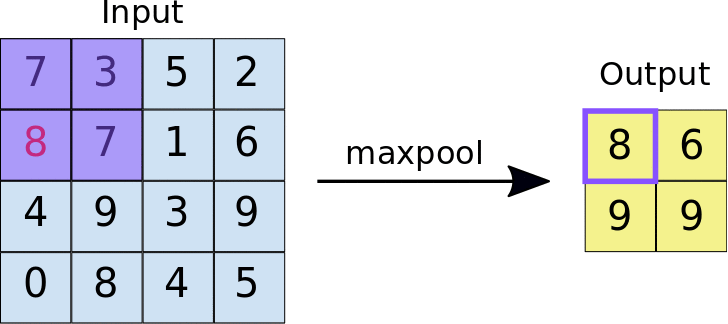

In [163]:
gif_path = "/content/drive/MyDrive/Pyladies_DeepLearning/img/maxpool.gif"
display(Image(filename=gif_path, width=400))

In [55]:
def residual_block(data, filters, kernel_tamano): #, d_rate
    shortcut = data
    bn1 = BatchNormalization(axis=-1)(data)
    act1 = Activation('relu')(bn1)
    #conv1 = Conv1D(filters, 1, dilation_rate=d_rate, padding='same', kernel_regularizer=regularizers.l2(0.0001))(act1)
    conv1 = Conv2D(filters,(kernel_tamano,kernel_tamano), strides=(1,1),padding='same', activation='relu')(act1) #,name='CONV1_RES' #same = agregar pading , strides sancadas de la conv bias_initializer='zeros',
    #bottleneck convolution
    bn2 = BatchNormalization(axis=-1)(conv1)
    act2 = Activation('relu')(bn2)
    #conv2 = Conv1D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(0.0001))(act2)
    conv2 = Conv2D(filters,(kernel_tamano,kernel_tamano), strides=(1,1),padding='same', activation='relu')(act2)#,name='CONV2_RES'
    #skip connection
    x = Add()([conv2, shortcut])
    return x

In [65]:
def modelo_clasificar_secuencias_biologicas(input_shape_,clases_total, numero_filtros, kernel_tamano):
    print("MODELO_CNN-RES",input_shape_)
    input_x = Input(shape=input_shape_)
    Z1 = Conv2D(numero_filtros,(kernel_tamano,kernel_tamano), strides=(1,1),padding='same',name='CONV1', activation='relu')(input_x) #same = agregar pading , strides sancadas de la conv bias_initializer='zeros',

    # bloques residuales
    res1 = residual_block(Z1, numero_filtros, kernel_tamano) #datos, filtros 128
    #res2 = residual_block(res1, numero_filtros, kernel_tamano) #datos, filtros 128
    #res3 = residual_block(res2, numero_filtros, kernel_tamano) #datos, filtros 128
    P1 = MaxPool2D(pool_size=(2,2), strides= 2, name='POOL1')(res1)
    # FLATTEN
    F1 = Flatten(name='FLAT')(P1)
    ## Dense layer
    FC1 =Dense(100, activation='relu',   name='fc_1')(F1) #bias_initializer='zeros', kernel_regularizer=regularizers.l2(0.0001),
    FC2= Dense(50, activation='relu', name='fc_2')(FC1) #bias_initializer='zeros',kernel_regularizer=regularizers.l2(0.0001),
    outputs_y = Dense(clases_total, activation='softmax',  name='fc_output')(FC2) #kernel_regularizer=regularizers.l2(0.0001),
    modelo_ = Model(inputs=input_x, outputs=outputs_y)
    return modelo_

In [66]:
model=modelo_clasificar_secuencias_biologicas((kmer_longitud, 26, 1), num_clases, Numero_filtros, tamano_kernel)

MODELO_CNN-RES (300, 26, 1)


In [67]:
opt_Adam = Adam(learning_rate=Learning_rate, name="Adam")

In [68]:
model.compile(optimizer=opt_Adam ,loss='categorical_crossentropy', metrics=['accuracy'])

In [69]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 26,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CONV1 (Conv2D)      │ (None, 300, 26,   │         80 │ input_layer_1[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 26,   │         32 │ CONV1[0][0]       │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 300, 26,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 300, 26,   │        584 │ activation_6[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 26,   │         32 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 300, 26,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 300, 26,   │        584 │ activation_7[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 300, 26,   │          0 │ conv2d_7[0][0],   │
│                     │ 8)                │            │ CONV1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ POOL1               │ (None, 150, 13,   │          0 │ add_3[0][0]       │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FLAT (Flatten)      │ (None, 15600)     │          0 │ POOL1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1 (Dense)        │ (None, 200)       │  3,120,200 │ FLAT[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_2 (Dense)        │ (None, 100)       │     20,100 │ fc_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_output (Dense)   │ (None, 3)         │        303 │ fc_2[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,141,915 (11.99 MB)

 Trainable params: 3,141,883 (11.99 MB)

 Non-trainable params: 32 (128.00 B)

## Entrenar

In [71]:
steps_train = len(df_train) // BatchSize
steps_val   = len(df_val) // BatchSize
print(steps_train, steps_val)

5177 647


In [72]:
history = model.fit(train_generador,epochs=Epocas,steps_per_epoch=steps_train,validation_data=val_generador,validation_steps=steps_val,verbose=1,initial_epoch=0, shuffle=True)

Epoch 1/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9104 - loss: 0.2502Generador::::
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 51s 9ms/step - accuracy: 0.9104 - loss: 0.2502 - val_accuracy: 0.9765 - val_loss: 0.0679
Epoch 2/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.9790 - loss: 0.0606 - val_accuracy: 0.9792 - val_loss: 0.0568
Epoch 3/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.9882 - loss: 0.0334 - val_accuracy: 0.9809 - val_loss: 0.0552
Epoch 4/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 81s 16ms/step - accuracy: 0.9931 - loss: 0.0198 - val_accuracy: 0.9807 - val_loss: 0.0672
Epoch 5/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 83s 16ms/step - accuracy: 0.9959 - loss: 0.0113 - val_accuracy: 0.9836 - val_loss: 0.0593
Epoch 6/6
5177/5177 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.9973 - loss: 0.0078 - val_accuracy: 0.9840 - val_loss: 0.0636


In [84]:
#Graficar las Perdida y la exactitud
def plot_history(history,longitud, batch, ler_rate):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy'+"_model:"+str(longitud)+"_batch:"+str(batch)+ "_lr:"+str(ler_rate))
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss'+"_model:"+str(longitud)+"_batch:"+str(batch)+ "_lr:"+str(ler_rate))
    plt.legend()
    plt.grid(True)
    #plt.savefig(grafica_save, dpi=300)
    plt.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{'accuracy': [0.945876955986023, 0.9810855984687805, 0.9894289374351501, 0.993286669254303, 0.9962388277053833, 0.9973436594009399], 'loss': [0.1491905152797699, 0.05285050347447395, 0.02940945513546467, 0.018131664022803307, 0.010568542405962944, 0.007707889657467604], 'val_accuracy': [0.9764779806137085, 0.9792039394378662, 0.9808966517448425, 0.9806548357009888, 0.9835566282272339, 0.9840402603149414], 'val_loss': [0.06794270873069763, 0.05679331719875336, 0.055185433477163315, 0.06724712252616882, 0.059349775314331055, 0.06355379521846771]}


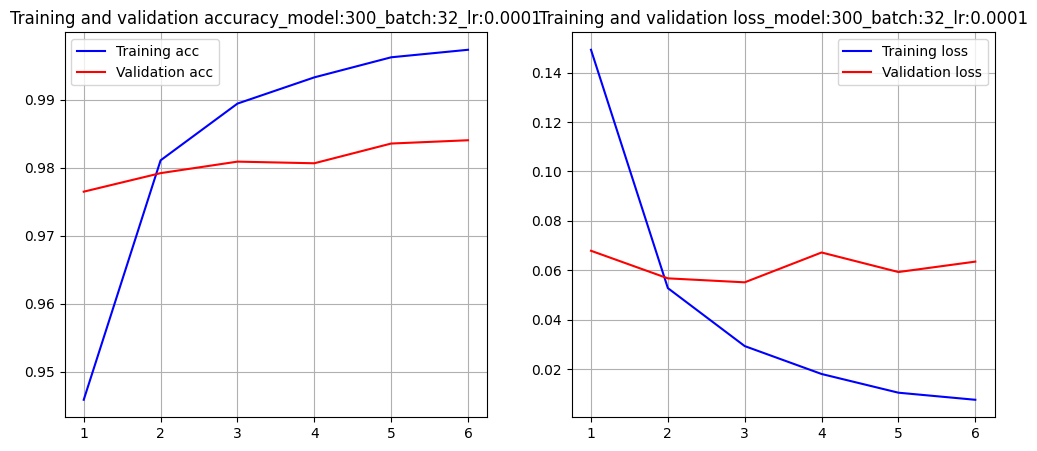

In [85]:
print(history.history.keys())
print(history.history)
plot_history(history,kmer_longitud, BatchSize, Learning_rate)

Test

In [124]:
def hacer_prediccion(kmer, model):
    kmer = np.expand_dims(kmer, axis=(0,-1)) #agregar dimencion al inicio y al final
    salida=model(kmer)
    salida_f = salida.numpy()
    max_value=salida_f.max()
    max_value=round(max_value,4)
    salida=np.rint(salida)
    clase_predicha=np.argmax(salida)
    #print("Salida----->",clase_predicha)
    return clase_predicha, max_value

In [125]:
print("::::::::::::::::::::::::  Predict ::::::::::::::::::::::::::::::")
print("Total de datos Test ----->", len(df_test))

::::::::::::::::::::::::  Predict ::::::::::::::::::::::::::::::
Total de datos Test -----> 20710


In [116]:
split_test=2
chunks_test=len(df_test)/split_test
print("Validar en Batchs de", chunks_test)
test_generador=generador(df_test, num_clases, int(chunks_test))

Validar en Batchs de 10355.0


In [119]:
#Declaramos las listas vacias donde se guardaran las predicciones y clases
lista_class_out=[]
lista_class_out_f=[]
y_original=[]

for i in range (split_test):
    print("Prediccion proceso-->", i+1 )
    prueba=next(test_generador)
    #Ver solo un ejemplo del generador
    entrada=prueba[0]
    y_original_=prueba[1]
    y_original_=np.array(y_original_, dtype='uint8')
    entrada=np.array(entrada, dtype='uint8')

    print("Salidas Originales:")
    #print(type(y_original_))
    #print(y_original_.shape)
    #print(y_original_)
    y_original_=np.argmax(y_original_, axis=1)
    print(y_original_)
    print("-------")
    bar = Bar('Loading', max=len(entrada) ,suffix='%(percent)d%%')
    #for i in range(len(entrada)):
    for i in tqdm(range(len(entrada)), desc=f"Predicción batch {i+1}"):
        clase_predicha, clase_predicha_f=hacer_prediccion(entrada[i], model)
        lista_class_out.append(clase_predicha)
        lista_class_out_f.append(clase_predicha_f)
        y_original.append(y_original_[i])
        bar.next()#Con esto podemos el progreso del ciclo
    bar.finish() #Con este finalizamos la barra de progreso

    #print(lista_class_out)
    #print(y_original)

    #Libreamos memoria
    del prueba
    del entrada
    del y_original_

Prediccion proceso--> 1
Salidas Originales:
[0 0 1 ... 0 2 0]
-------


Predicción batch 1:   0%|          | 0/10355 [00:00<?, ?it/s]

Prediccion proceso--> 2
Salidas Originales:
[0 0 0 ... 0 0 1]
-------


Predicción batch 2:   0%|          | 0/10355 [00:00<?, ?it/s]

In [126]:
salida=pd.DataFrame()
salida['salidas_originales']=y_original
salida['salidas_predichas']=lista_class_out
salida['certeza']=lista_class_out_f
salida

,salidas_originales,salidas_predichas,certeza
0,0,0,1.0000
1,0,0,1.0000
2,1,1,1.0000
3,2,2,1.0000
4,0,0,1.0000
...,...,...,...
20705,0,0,1.0000
20706,0,0,1.0000
20707,0,0,1.0000
20708,0,0,1.0000


In [129]:
labels_clases=["SARS-CoV-2", "Orthoherpesvirus", "Bacteriófagos"]

In [130]:
reporte = classification_report(y_original, lista_class_out, target_names=labels_clases, output_dict=True)
df_report = pd.DataFrame(reporte).transpose()  # usa df_report como nombre final
df_report = df_report.round(2)  # redondea
print(df_report)

                  precision  recall  f1-score   support
SARS-CoV-2             1.00    1.00      1.00  16036.00
Orthoherpesvirus       0.94    0.94      0.94   2239.00
Bacteriófagos          0.94    0.94      0.94   2435.00
accuracy               0.98    0.98      0.98      0.98
macro avg              0.96    0.96      0.96  20710.00
weighted avg           0.98    0.98      0.98  20710.00


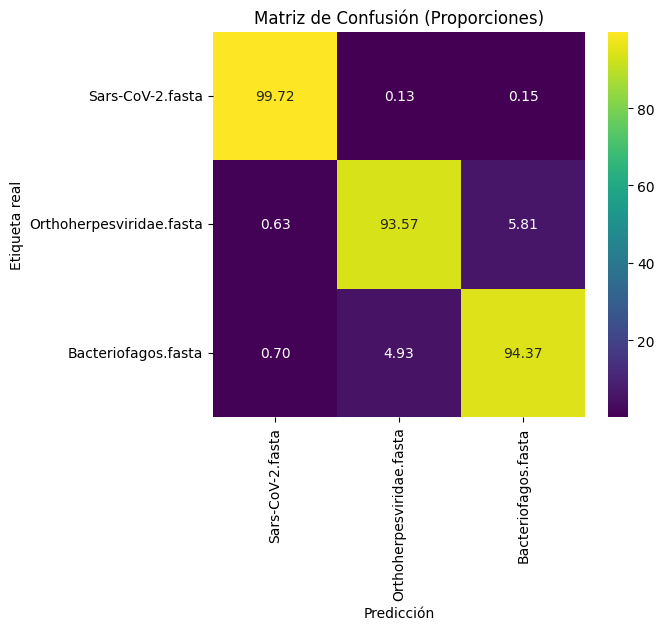

In [135]:
#Matriz de Confusion

# Calcular matriz de confusión
cm = confusion_matrix(y_original, lista_class_out)
# Normalizar por filas (porcentaje de cada clase real)
cm_normalized_ = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
cm_normalized=cm_normalized_*100
# Hacer el gráfico
plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión (Proporciones)")
plt.show()

# Predicción externa

Selecciona tu archivo FASTA...


Saving Seq_combinada.fasta to Seq_combinada (10).fasta
Número de k-mers generados: 10
[[9.9999940e-01 5.6929952e-07 1.2661613e-08]
 [9.9999905e-01 3.9111512e-07 5.5207386e-07]
 [9.9999893e-01 2.9067618e-07 8.5150515e-07]
 [9.9999738e-01 2.1039739e-06 4.9633070e-07]
 [9.9999976e-01 2.9875988e-09 1.8775320e-07]
 [9.9974436e-01 2.4747895e-04 8.0929758e-06]
 [9.9499309e-01 3.7090501e-03 1.2978449e-03]
 [9.2488235e-01 7.1878664e-02 3.2389695e-03]
 [1.1546423e-02 8.8428032e-01 1.0417319e-01]
 [1.0273704e-04 3.3046510e-02 9.6685076e-01]]
                                                                                                                                                                                                                                                                                                           Kmer  \
0  MFVFLVLLPLVSSQCVNLITRTQSYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPALPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLDVYQKNNKSWMESEF

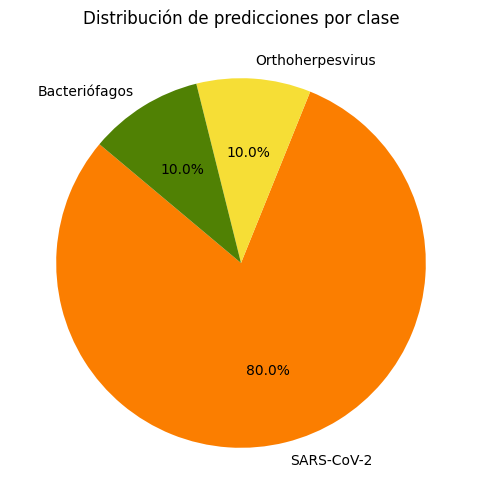

In [159]:
# 1. Subir archivo FASTA
print("Selecciona tu archivo FASTA...")
uploaded = files.upload()
fasta_path = list(uploaded.keys())[0]

# 2. Generar kmers usando tu función
df_kmers = kmerizar_fasta(fasta_path, kmer_longitud=300, step=40, clase="0") #usar 0 por default aun que no es la clase en si
print("Número de k-mers generados:", len(df_kmers))

# 3. Codificar kmers con tu función recorre_lineas
lista_datos = []
for _, fila in df_kmers.iterrows():
    linea_nueva, _=recorre_lineas(fila)  # <- fila['Kmer'] y fila['Clase'] existen
    lista_datos.append(linea_nueva)

# Convertir a array y a one-hot
x_data = np.array(lista_datos, dtype="uint8")
x_data = to_categorical(x_data, num_classes=26)
x_data = x_data.astype("uint8")

# 4. Pasar al modelo
predicciones = model.predict(x_data, verbose=0)
print(predicciones)

# 5. Obtener clase predicha por cada kmer
# Para cada kmer, probabilidad máxima (softmax de la clase predicha)
certezas = np.max(predicciones, axis=1) * 100  # en %
clases_predichas = np.argmax(predicciones, axis=1)

# 6. Crear DataFrame con resultados
#labels = ["SARS-CoV-2", "Orthoherpesvirus", "Bacteriófagos"]
df_resultados = pd.DataFrame({
    "Kmer": df_kmers["Kmer"],
    "Predicción": [labels[c] for c in clases_predichas],
    "%Certeza": certezas.round(2)
})
print(df_resultados)
# 7. Resumen de proporciones por clase
resumen = df_resultados["Predicción"].value_counts(normalize=True) * 100
print("\nResumen de predicciones (% por clase):")
print(resumen.round(2))


# 8. Graficar pie chart
# Definir paleta: un color
colores = {
    "SARS-CoV-2": "#FB7E00",       # naranjoso
    "Orthoherpesvirus": "#f6de36", # amarillo
    "Bacteriófagos": "#508104"     # verde
}
plt.figure(figsize=(6,6))
plt.pie(
    resumen,
    labels=resumen.index,
    autopct="%.1f%%",
    startangle=140,
    colors=[colores[clase] for clase in resumen.index]  # colores fijoss
)
plt.title("Distribución de predicciones por clase")
plt.show()



---


# Créditos y agradecimientos

Este taller fue desarrollado e impartido por:

Alida Esmeralda Zárate Jiménez
🔗 GitHub: @alyzart22


❤️ Agradecimientos especiales
PyLadies Cuernavaca por la organización del evento y su compromiso con la formación de mujeres en tecnología.

Esta notebook fue creada como recurso educativo para el taller:

Puedes reutilizar este material para fines educativos con atribución correspondiente.

Licencia: Creative Commons BY-NC-SA 4.0